[*********************100%***********************]  1 of 1 completed

Train: 3521 obs. | Test: 251 obs.
Período test: 2024-01-02 → 2024-12-30

Total combinaciones a evaluar: 72
Esto puede tardar varios minutos. Ten paciencia.

[  1/72] LSTM | L=20 | units=32 | drop=0.1 | layers=1 ... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


MAPE=0.5882%(52s, 80 épocas)

[  2/72] LSTM | L=20 | units=32 | drop=0.1 | layers=2 ... MAPE=0.5876%(78s, 80 épocas)
[  3/72] LSTM | L=20 | units=32 | drop=0.2 | layers=1 ... MAPE=0.5877%(54s, 80 épocas)
[  4/72] LSTM | L=20 | units=32 | drop=0.2 | layers=2 ... MAPE=0.5858%(84s, 80 épocas)
[  5/72] LSTM | L=20 | units=32 | drop=0.3 | layers=1 ... MAPE=0.5875%(51s, 80 épocas)
[  6/72] LSTM | L=20 | units=32 | drop=0.3 | layers=2 ... MAPE=0.5839%(71s, 80 épocas)
[  7/72] LSTM | L=20 | units=64 | drop=0.1 | layers=1 ... MAPE=0.5856%(59s, 80 épocas)
[  8/72] LSTM | L=20 | units=64 | drop=0.1 | layers=2 ... MAPE=0.5849%(95s, 80 épocas)
[  9/72] LSTM | L=20 | units=64 | drop=0.2 | layers=1 ... MAPE=0.5894%(63s, 80 épocas)
[ 10/72] LSTM | L=20 | units=64 | drop=0.2 | layers=2 ... MAPE=0.5902%(92s, 80 épocas)
[ 11/72] LSTM | L=20 | units=64 | drop=0.3 | layers=1 ... MAPE=0.5884%(72s, 80 épocas)
[ 12/72] LSTM | L=20 | units=64 | drop=0.3 | layers=2 ... MAPE=0.5838%(99s, 80 épocas)
[ 13/72] LSTM

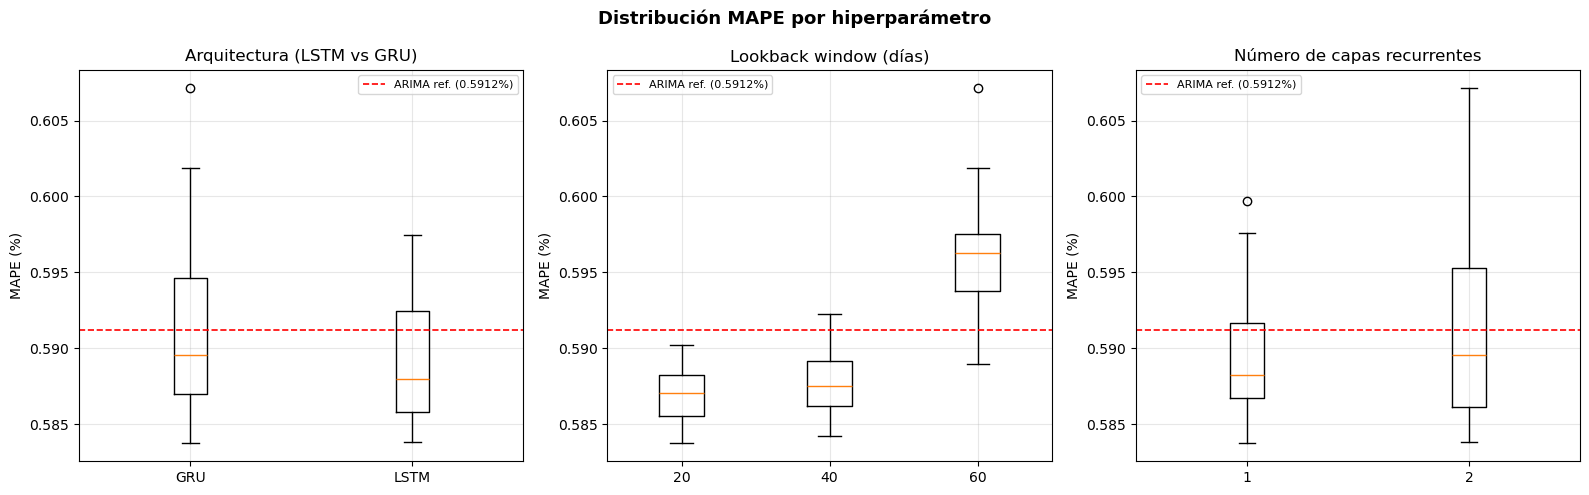

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import time

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 1
np.random.seed(SEED)
tf.random.set_seed(SEED)

# REFERENCIA ARIMA para comparación directa en tablas
# ─────────────────────────────────────────────────────────────────────────────
ARIMA_REF = {"MAE": 3.1912, "RMSE": 4.3229, "MAPE": 0.5912}

# ══════════════════════════════════════════════════════════════════════════════
# DATOS Y SPLIT

df = yf.download("SPY", start="2010-01-01", end="2024-12-31",
                 interval="1d", auto_adjust=False)
df = df[["Close"]]
df["Change %"]   = df["Close"].pct_change() * 100
df = df.dropna()

fecha_corte = df.index.max() - pd.DateOffset(years=1)
df_train    = df[df.index <  fecha_corte].copy()
df_test     = df[df.index >= fecha_corte].copy()

print(f"Train: {len(df_train)} obs. | Test: {len(df_test)} obs.")
print(f"Período test: {df_test.index[0].date()} → {df_test.index[-1].date()}")

# ══════════════════════════════════════════════════════════════════════════════
# NORMALIZACIÓN

FEATURES   = ["Change %"]

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train[FEATURES].values)

arr_scaled    = scaler.transform(df[FEATURES].values)
train_end_pos = len(df_train)

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def descalar_retorno(pred_scaled):
    # Invierte el escalado para la columna Change %
    aux = np.zeros((len(pred_scaled), len(FEATURES)))
    aux[:, 0] = pred_scaled
    return scaler.inverse_transform(aux)[:, 0]

# ══════════════════════════════════════════════════════════════════════════════
# MÉTRICAS

def calcular_metricas(pred_ret_pct, real_ret_pct, precio_previo, precio_real):
    # — Precio reconstruido desde retorno predicho
    pred_precio = precio_previo * (1 + pred_ret_pct / 100)

    # — Métricas en escala de precios
    errores = precio_real - pred_precio
    mae     = float(np.abs(errores).mean())
    rmse    = float(np.sqrt((errores ** 2).mean()))
    mape    = float((np.abs(errores) / precio_real).mean() * 100)

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# ══════════════════════════════════════════════════════════════════════════════
# CONSTRUCCIÓN DE MODELOS

def build_model(arch, lookback, n_features, units, dropout, n_layers):
    
    # arch     : 'LSTM' o 'GRU'
    # n_layers : 1 o 2 capas recurrentes apiladas

    Layer = LSTM if arch == "LSTM" else GRU
    model = Sequential()

    # Diferenciamos entre una y dos capas
    if n_layers == 1:
        model.add(Layer(units, input_shape=(lookback, n_features)))
        model.add(Dropout(dropout))
    else:
        model.add(Layer(units, return_sequences=True,
                        input_shape=(lookback, n_features)))
        model.add(Dropout(dropout))
        model.add(Layer(units // 2))
        model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer="sgd", loss="mse")
    return model

# ══════════════════════════════════════════════════════════════════════════════
# GRID SEARCH
# Para cada combinación de hiperparámetros:
#  a) Entrena sobre train completo
#  b) Rolling forecast sobre test (ventana deslizante, pesos fijos)
#  c) Calcula todas las métricas

# Espacio de búsqueda
GRID = {
    "arch"    : ["LSTM", "GRU"],
    "lookback": [20, 40, 60],
    "units"   : [32, 64],
    "dropout" : [0.1, 0.2, 0.3],
    "n_layers": [1, 2],
}

# Datos fijos para las métricas de precio
precio_real_test = df_test["Close"].values
precio_prev_test = np.concatenate([[df_train["Close"].iloc[-1]], precio_real_test[:-1] ])
real_ret_pct_test = df_test["Change %"].values

# Combinaciones totales
combos = list(itertools.product( GRID["arch"], GRID["lookback"], GRID["units"], GRID["dropout"], GRID["n_layers"]))
print(f"\nTotal combinaciones a evaluar: {len(combos)}")
print("Esto puede tardar varios minutos. Ten paciencia.\n")

resultados = []
t0_total = time.time()

for idx, (arch, L, units, dropout, n_layers) in enumerate(combos, 1):

    etiqueta = (f"{arch} | L={L} | units={units} "
                f"| drop={dropout} | layers={n_layers}")
    print(f"[{idx:3d}/{len(combos)}] {etiqueta}", end=" ... ", flush=True)
    t0 = time.time()

    # ── Secuencias de entrenamiento ──────────────────────────────────────
    X_tr, y_tr = make_sequences(arr_scaled[:train_end_pos], L)

    # ── Entrenamiento ────────────────────────────────────────────────────
    model = build_model(arch, L, len(FEATURES), units, dropout, n_layers)
    hist  = model.fit(
        X_tr, y_tr,
        validation_split=0.1,
        epochs=80,
        batch_size=32,
        verbose=0
    )
    epocas_reales = len(hist.history["loss"])

    # ── Rolling forecast sobre test ──────────────────────────────────────
    historia = list(arr_scaled[:train_end_pos])
    pred_scaled_list = []

    for i in range(len(df_test)):
        ventana = np.array(historia[-L:]).reshape(1, L, len(FEATURES))
        pred_s  = float(model.predict(ventana, verbose=0).ravel()[0])
        pred_scaled_list.append(pred_s)
        historia.append(arr_scaled[train_end_pos + i])

    pred_ret_pct = descalar_retorno(np.array(pred_scaled_list))

    # ── Métricas ─────────────────────────────────────────────────────────
    metricas = calcular_metricas(pred_ret_pct, real_ret_pct_test, precio_prev_test, precio_real_test)

    elapsed = time.time() - t0
    print(f"MAPE={metricas['MAPE']:.4f}%" f"({elapsed:.0f}s, {epocas_reales} épocas)")

    resultados.append({
        "Arquitectura": arch,
        "Lookback"    : L,
        "Unidades"    : units,
        "Dropout"     : dropout,
        "Capas"       : n_layers,
        "Épocas"      : epocas_reales,
        **metricas
    })

    # Libera memoria
    tf.keras.backend.clear_session()

print(f"\nTiempo total: {(time.time()-t0_total)/60:.1f} min")

# ══════════════════════════════════════════════════════════════════════════════
# TABLA DE RESULTADOS


df_res = pd.DataFrame(resultados)

# Ordenamos por MAPE (métrica principal para comparar con ARIMA)
df_res = df_res.sort_values("MAPE").reset_index(drop=True)

print("\n" + "═"*95)
print("  RESULTADOS GRID SEARCH — ordenados por MAPE (escala precios)")
print("═"*95)
print(df_res.to_string(index=True, float_format="{:.4f}".format))
print("═"*95)

# Añadimos fila de referencia ARIMA
print(f"\n  Referencia ARIMA(0,1,0): "
      f"MAE={ARIMA_REF['MAE']:.4f}  "
      f"RMSE={ARIMA_REF['RMSE']:.4f}  "
      f"MAPE={ARIMA_REF['MAPE']:.4f}%  ")

# Top 5
print("\n── Top 5 modelos por MAPE ──")
print(df_res.head(5).to_string(index=True, float_format="{:.4f}".format))


# ══════════════════════════════════════════════════════════════════════════════
# Box-plot de resultados

# ── Boxplot MAPE por arquitectura ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titulo in zip(
        axes,
        ["Arquitectura", "Lookback", "Capas"],
        ["Arquitectura (LSTM vs GRU)",
         "Lookback window (días)",
         "Número de capas recurrentes"]):
    grupos = [df_res[df_res[col] == v]["MAPE"].values
              for v in sorted(df_res[col].unique())]
    labels = sorted(df_res[col].unique())
    ax.boxplot(grupos, labels=labels)
    ax.axhline(ARIMA_REF["MAPE"], color="red", linestyle="--",
               linewidth=1.2, label=f"ARIMA ref. ({ARIMA_REF['MAPE']:.4f}%)")
    ax.set_title(titulo); ax.set_ylabel("MAPE (%)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Distribución MAPE por hiperparámetro", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()

In [2]:
# ── Tabla resumen final con ARIMA ─────────────────────────────────────
mejor_lstm = df_res[df_res["Arquitectura"] == "LSTM"].iloc[0]
mejor_gru  = df_res[df_res["Arquitectura"] == "GRU"].iloc[0]

print("\n" + "═"*70)
print("  TABLA RESUMEN COMPARATIVA")
print("═"*70)
print(f"  {'Modelo':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} ")
print("─"*70)

def fila(nombre, row):
    return (f"  {nombre:<30} {row['MAE']:>8.4f} {row['RMSE']:>8.4f}" f"{row['MAPE']:>7.4f}%")

print(fila(f"LSTM (mejor: L={int(mejor_lstm['Lookback'])},"
           f"u={int(mejor_lstm['Unidades'])},"
           f"d={mejor_lstm['Dropout']},"
           f"c={int(mejor_lstm['Capas'])})", mejor_lstm))
print(fila(f"GRU  (mejor: L={int(mejor_gru['Lookback'])},"
           f"u={int(mejor_gru['Unidades'])},"
           f"d={mejor_gru['Dropout']},"
           f"c={int(mejor_gru['Capas'])})", mejor_gru))
print(f"  {'ARIMA(0,1,0)':<30} "
      f"{ARIMA_REF['MAE']:>8.4f} {ARIMA_REF['RMSE']:>8.4f} "
      f"{ARIMA_REF['MAPE']:>7.4f}%")
print("═"*70)


══════════════════════════════════════════════════════════════════════
  TABLA RESUMEN COMPARATIVA
══════════════════════════════════════════════════════════════════════
  Modelo                              MAE     RMSE     MAPE 
──────────────────────────────────────────────────────────────────────
  LSTM (mejor: L=20,u=64,d=0.3,c=2)   3.1497   4.3035 0.5838%
  GRU  (mejor: L=20,u=64,d=0.1,c=1)   3.1493   4.3036 0.5837%
  ARIMA(0,1,0)                     3.1912   4.3229  0.5912%
══════════════════════════════════════════════════════════════════════
